In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

2026-04-19 04:40:01.354074: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776573601.546123      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776573601.605188      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776573602.073320      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776573602.073363      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776573602.073366      55 computation_placer.cc:177] computation placer alr

In [3]:
train_dir = "/kaggle/input/datasets/rm1000/skin-cancer-isic-images"

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 2638 images belonging to 2 classes.
Found 659 images belonging to 2 classes.


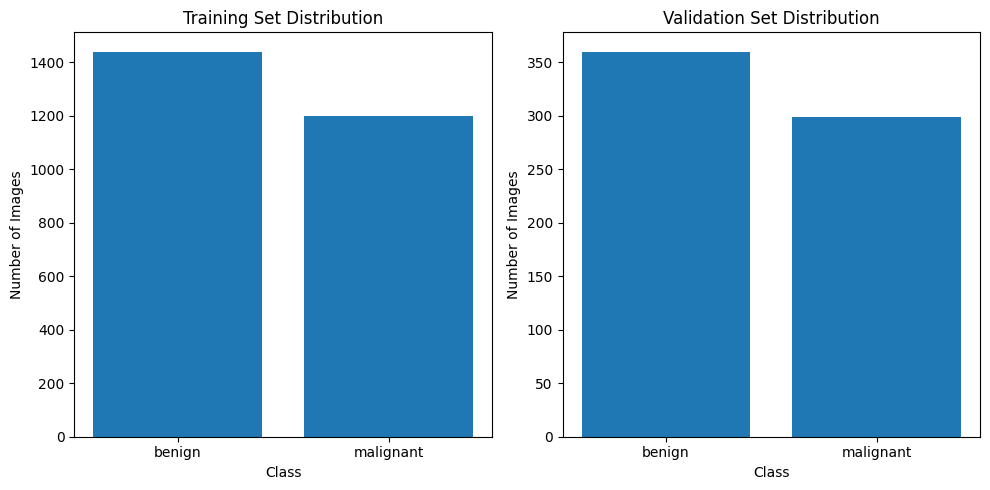

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_class_distribution(train_gen, val_gen):
    # Get class labels
    class_labels = list(train_gen.class_indices.keys())
    
    # Count images per class
    train_counts = np.bincount(train_gen.classes)
    val_counts = np.bincount(val_gen.classes)

    x = np.arange(len(class_labels))

    plt.figure(figsize=(10,5))

    # Train set
    plt.subplot(1,2,1)
    plt.bar(x, train_counts)
    plt.xticks(x, class_labels)
    plt.title("Training Set Distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of Images")

    # Validation set
    plt.subplot(1,2,2)
    plt.bar(x, val_counts)
    plt.xticks(x, class_labels)
    plt.title("Validation Set Distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of Images")

    plt.tight_layout()
    plt.show()

plot_class_distribution(train_generator, val_generator)

In [6]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} Loss')
    plt.legend()

    plt.show()

In [7]:
def evaluate_model(model, generator, name):
    y_true = generator.classes
    y_pred_prob = model.predict(generator)
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Classification Report
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_true, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0,1],[0,1],'--')
    plt.title(f'{name} ROC Curve')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.legend()
    plt.show()

## Custom CNN

In [8]:
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1776573651.656652      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776573651.662408      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can i

Epoch 1/10


I0000 00:00:1776573656.287058     144 service.cc:152] XLA service 0x78b7cc005450 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776573656.287097     144 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776573656.287100     144 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776573656.711006     144 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-19 04:40:59.289302: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 04:40:59.438406: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 2/83 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.5156 - loss: 0.7001 

I0000 00:00:1776573662.101246     144 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


65/83 ━━━━━━━━━━━━━━━━━━━━ 9s 543ms/step - accuracy: 0.6216 - loss: 0.6415 

2026-04-19 04:41:38.514600: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 04:41:38.659346: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


83/83 ━━━━━━━━━━━━━━━━━━━━ 69s 738ms/step - accuracy: 0.6358 - loss: 0.6267 - val_accuracy: 0.8088 - val_loss: 0.4154
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 36s 430ms/step - accuracy: 0.7497 - loss: 0.4793 - val_accuracy: 0.7891 - val_loss: 0.4419
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 444ms/step - accuracy: 0.7740 - loss: 0.4327 - val_accuracy: 0.8179 - val_loss: 0.3872
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 442ms/step - accuracy: 0.7543 - loss: 0.4694 - val_accuracy: 0.8194 - val_loss: 0.3577
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 442ms/step - accuracy: 0.8074 - loss: 0.4137 - val_accuracy: 0.8331 - val_loss: 0.3729
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 445ms/step - accuracy: 0.8021 - loss: 0.4112 - val_accuracy: 0.8255 - val_loss: 0.3561
Epoch 7/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 444ms/step - accuracy: 0.8119 - loss: 0.4146 - val_accuracy: 0.8361 - val_loss: 0.3599
Epoch 8/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 36s 435ms/step - accuracy: 0.8149 - loss: 0.3802 - val_accuracy: 0.814

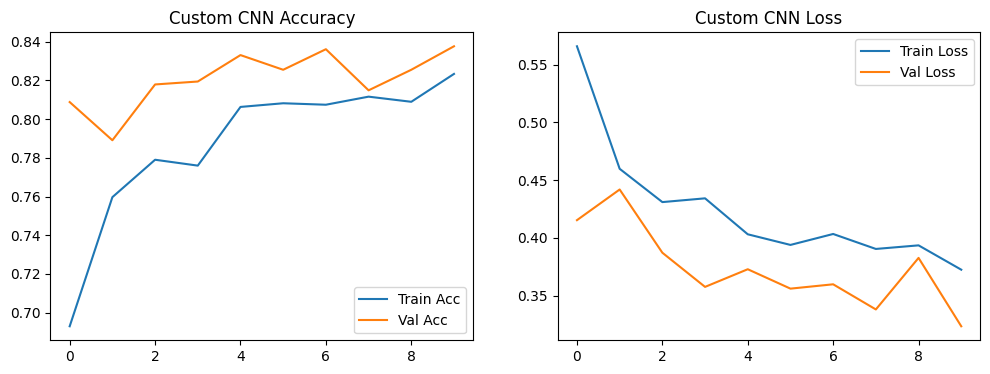

In [9]:
plot_history(cnn_history, "Custom CNN")

21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 335ms/step


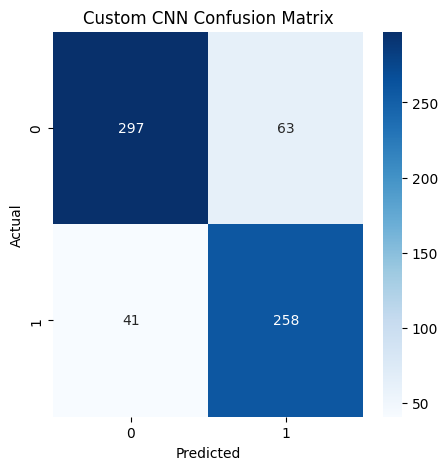


Custom CNN Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.82      0.85       360
           1       0.80      0.86      0.83       299

    accuracy                           0.84       659
   macro avg       0.84      0.84      0.84       659
weighted avg       0.84      0.84      0.84       659



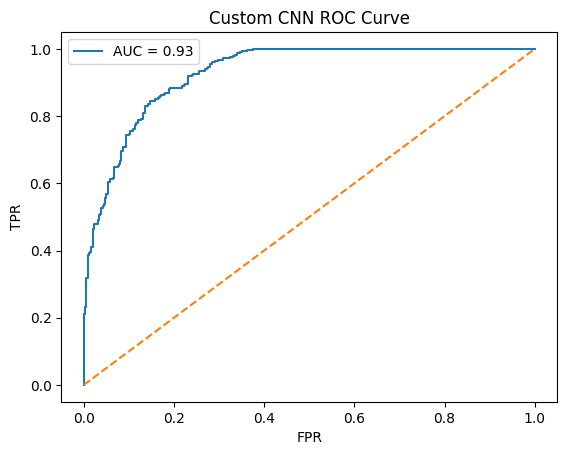

In [10]:
evaluate_model(cnn_model, val_generator, "Custom CNN")

## ResNet50

In [11]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

resnet_model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

resnet_history = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 61s 604ms/step - accuracy: 0.5242 - loss: 0.8672 - val_accuracy: 0.5463 - val_loss: 0.6801
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 443ms/step - accuracy: 0.5599 - loss: 0.6821 - val_accuracy: 0.5721 - val_loss: 0.6761
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 36s 435ms/step - accuracy: 0.5529 - loss: 0.6853 - val_accuracy: 0.5493 - val_loss: 0.6762
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 36s 436ms/step - accuracy: 0.5683 - loss: 0.6783 - val_accuracy: 0.5690 - val_loss: 0.6710
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 443ms/step - accuracy: 0.5748 - loss: 0.6713 - val_accuracy: 0.6039 - val_loss: 0.6704
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 440ms/step - accuracy: 0.5884 - loss: 0.6726 - val_accuracy: 0.5842 - val_loss: 0.6611
Epoch 7/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 447ms/step - accuracy: 0.5866 - loss: 0.6671 - val_accuracy: 0.6085 - val_loss: 0.6560
Epoch 8/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 448m

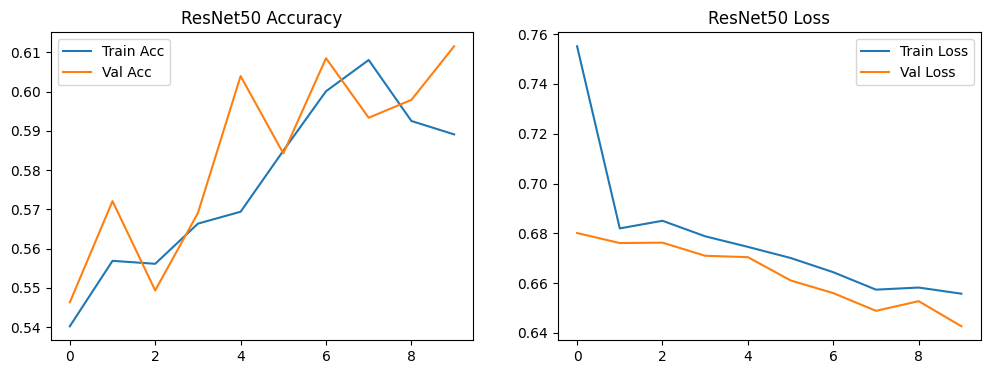

In [12]:
plot_history(resnet_history, "ResNet50")

21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 527ms/step


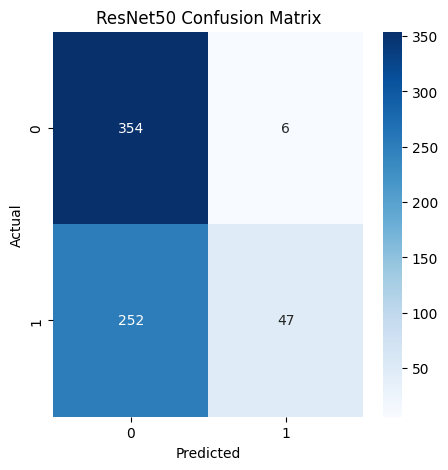


ResNet50 Classification Report:

              precision    recall  f1-score   support

           0       0.58      0.98      0.73       360
           1       0.89      0.16      0.27       299

    accuracy                           0.61       659
   macro avg       0.74      0.57      0.50       659
weighted avg       0.72      0.61      0.52       659



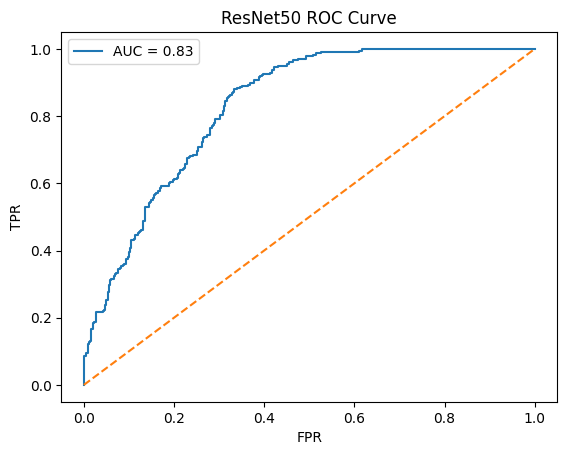

In [13]:
evaluate_model(resnet_model, val_generator, "ResNet50")

## MobileNetV2

In [14]:
base_model_m = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model_m.trainable = False

mobilenet_model = Sequential([
    base_model_m,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mobilenet_history = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10


2026-04-19 04:56:21.878057: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 04:56:22.015966: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


42/83 ━━━━━━━━━━━━━━━━━━━━ 14s 351ms/step - accuracy: 0.6918 - loss: 0.8274

2026-04-19 04:56:47.515697: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 04:56:47.653490: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.7224 - loss: 0.7067

2026-04-19 04:57:24.675595: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 04:57:24.812828: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


83/83 ━━━━━━━━━━━━━━━━━━━━ 79s 758ms/step - accuracy: 0.7229 - loss: 0.7048 - val_accuracy: 0.8042 - val_loss: 0.4169
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 441ms/step - accuracy: 0.8133 - loss: 0.4099 - val_accuracy: 0.8300 - val_loss: 0.3800
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 445ms/step - accuracy: 0.8351 - loss: 0.3705 - val_accuracy: 0.8316 - val_loss: 0.3897
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 563ms/step - accuracy: 0.8464 - loss: 0.3406 - val_accuracy: 0.8164 - val_loss: 0.3807
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 54s 658ms/step - accuracy: 0.8528 - loss: 0.3284 - val_accuracy: 0.8452 - val_loss: 0.3748
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 446ms/step - accuracy: 0.8593 - loss: 0.3201 - val_accuracy: 0.8316 - val_loss: 0.3678
Epoch 7/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 36s 440ms/step - accuracy: 0.8778 - loss: 0.2924 - val_accuracy: 0.8255 - val_loss: 0.3535
Epoch 8/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 36s 433ms/step - accuracy: 0.8712 - loss: 0.3086 - val_accuracy: 0.846

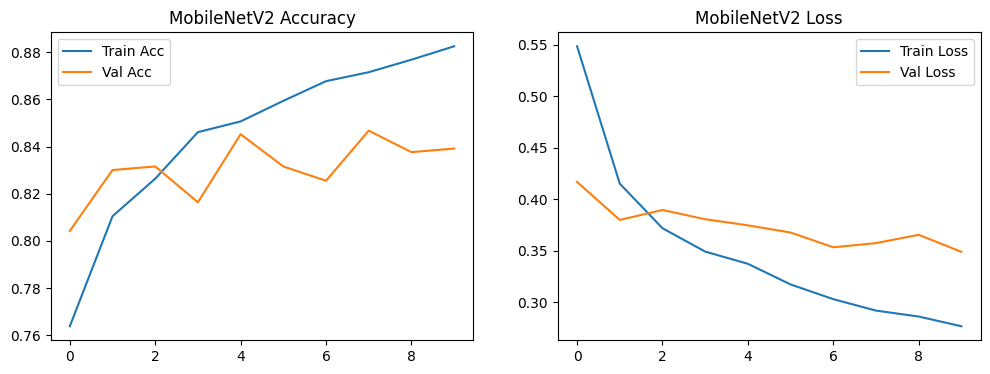

In [15]:
plot_history(mobilenet_history, "MobileNetV2")

21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 532ms/step


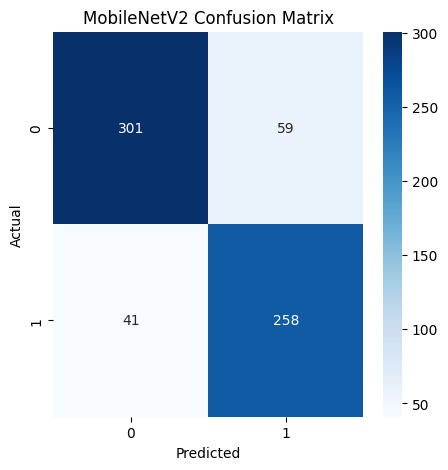


MobileNetV2 Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.84      0.86       360
           1       0.81      0.86      0.84       299

    accuracy                           0.85       659
   macro avg       0.85      0.85      0.85       659
weighted avg       0.85      0.85      0.85       659



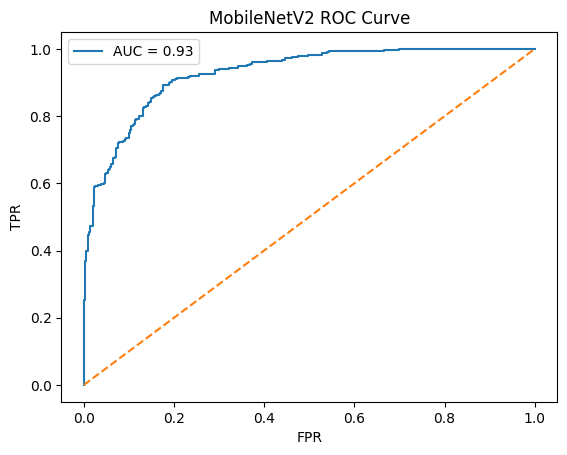

In [16]:
evaluate_model(mobilenet_model, val_generator, "MobileNetV2")

## Model comparison

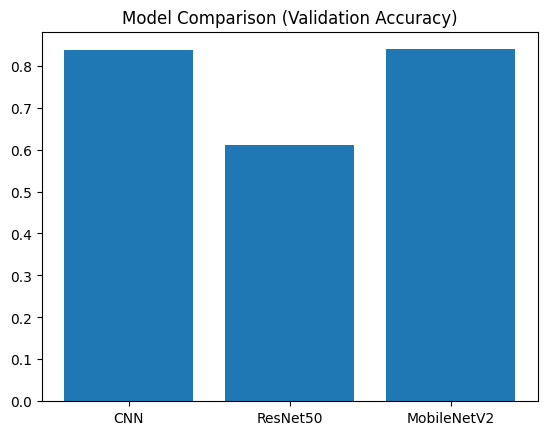

In [17]:
models = ['CNN', 'ResNet50', 'MobileNetV2']
accuracies = [
    cnn_history.history['val_accuracy'][-1],
    resnet_history.history['val_accuracy'][-1],
    mobilenet_history.history['val_accuracy'][-1]
]

plt.bar(models, accuracies)
plt.title("Model Comparison (Validation Accuracy)")
plt.show()